# Supp Fig 9 — FP-specific POU2F3+/ASCL2+ tuft-like (Hippo/Wnt/TGF-β)

Reproduces **SuppFig9** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 9 — tuft score + FP_specific vs TN_tuft DE (cell 74)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 74`

In [ ]:
# Tuft markers (canonical chemosensory tuft cell signature)
TUFT_MARKERS = ['POU2F3', 'TRPM5', 'DCLK1', 'AVIL', 'GFI1B', 'SPIB',
                 'CHAT', 'LRMP', 'IRAG2', 'SH2D6', 'BMX', 'HCK',
                 'IL25', 'PLCB2', 'ALOX5']

present_tuft = [g for g in TUFT_MARKERS if g in adata_score.var_names]
print(f'Tuft markers found: {len(present_tuft)}/{len(TUFT_MARKERS)}: {present_tuft}')
missing = [g for g in TUFT_MARKERS if g not in adata_score.var_names]
if missing: print(f'  missing from HVG: {missing}')

sc.tl.score_genes(adata_score, gene_list=present_tuft, score_name='tuft_score',
                   random_state=42, use_raw=False)

print('\nTuft score by group_extended:')
summary = adata_score.obs.groupby('group_extended', observed=True)['tuft_score'].agg(
    ['mean','median','std','count']).sort_values('mean', ascending=False)
print(summary.to_string())

# Define TN-tuft: top 5% tuft score within TN
tn_mask = (adata_score.obs['group_extended'].values == 'TN')
tn_tuft_thr = float(np.percentile(adata_score.obs.loc[tn_mask, 'tuft_score'].values, 95))
print(f'\nTN tuft threshold (top 5%): {tn_tuft_thr:.3f}')
adata_score.obs['is_TN_tuft'] = tn_mask & (adata_score.obs['tuft_score'].values >= tn_tuft_thr)
n_tn_tuft = int(adata_score.obs['is_TN_tuft'].sum())
print(f'TN-tuft cells: n={n_tn_tuft}')

# How tuft-like are FP-specific?
fp_spec_mask = (adata_score.obs['group_extended'].values == 'FP_specific')
fp_tuft_pass = float((adata_score.obs.loc[fp_spec_mask, 'tuft_score'].values >= tn_tuft_thr).mean() * 100)
print(f'FP-specific cells exceeding TN tuft threshold: {fp_tuft_pass:.1f}% (n_FP_spec={int(fp_spec_mask.sum())})')
print(f'  → suggests FP_specific is {"strongly" if fp_tuft_pass > 50 else "partially" if fp_tuft_pass > 20 else "minimally"} tuft-like')

# DE: FP_specific vs TN_tuft (re-normalize from adata_int counts for clean log2FC)
a = adata_int.copy()
a.uns.pop('log1p', None)
a.X = a.layers['counts'].copy()
if a.X.dtype.kind in ('i','u'):
    a.X = a.X.astype(np.float32)
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)

# Map group classification onto re-normed adata
a.obs['de_class'] = 'other'
fp_spec_names = adata_score.obs_names[fp_spec_mask]
tn_tuft_names  = adata_score.obs_names[adata_score.obs['is_TN_tuft'].values]
a.obs.loc[a.obs_names.isin(fp_spec_names), 'de_class'] = 'FP_specific'
a.obs.loc[a.obs_names.isin(tn_tuft_names),  'de_class'] = 'TN_tuft'

sub = a[a.obs['de_class'].isin(['FP_specific', 'TN_tuft'])].copy()
sub.obs['de_class'] = pd.Categorical(sub.obs['de_class'].astype(str).values,
                                       categories=['TN_tuft', 'FP_specific'])
print(f'\nDE: FP_specific (n={int((sub.obs["de_class"]=="FP_specific").sum())}) '
      f'vs TN_tuft (n={int((sub.obs["de_class"]=="TN_tuft").sum())})')
sc.tl.rank_genes_groups(sub, 'de_class', groups=['FP_specific'], reference='TN_tuft',
                         method='wilcoxon', use_raw=False)
res = sub.uns['rank_genes_groups']
de_fp_vs_tntuft = pd.DataFrame({
    'gene':   [r[0] for r in res['names']],
    'log2FC': [r[0] for r in res['logfoldchanges']],
    'p':      [r[0] for r in res['pvals']],
    'p_adj':  [r[0] for r in res['pvals_adj']],
})
de_fp_vs_tntuft.to_csv(OUT_DIR / 'de_FP_specific_vs_TN_tuft.csv.gz',
                        index=False, compression='gzip')
print(f'Saved: {OUT_DIR / "de_FP_specific_vs_TN_tuft.csv.gz"}')

sig = de_fp_vs_tntuft.dropna(subset=['p_adj'])
sig = sig[sig['p_adj'] < 0.05]
up = sig[sig['log2FC'] > 1].sort_values('log2FC', ascending=False).head(15)
dn = sig[sig['log2FC'] < -1].sort_values('log2FC').head(15)
print(f'\nTop 15 UP in FP_specific (vs TN_tuft):')
print(up[['gene','log2FC','p_adj']].to_string(index=False))
print(f'\nTop 15 UP in TN_tuft (vs FP_specific):')
print(dn[['gene','log2FC','p_adj']].to_string(index=False))

### Supp Fig 9 — tuft violin/volcano/marker heatmap (cell 75)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 75`

In [ ]:
from scipy import sparse as sp_

# ── 1) Tuft score violin per group (with TN split into non-tuft + tuft) ──
groups_to_plot = ['TP', 'FN_rest', 'FN_specific', 'FP_specific', 'FP_rest']
data_per, labels_per, colors_per = [], [], []
for g in groups_to_plot:
    m = adata_score.obs['group_extended'].values == g
    if not m.any(): continue
    data_per.append(adata_score.obs.loc[m, 'tuft_score'].values)
    labels_per.append(f'{g}\nn={int(m.sum()):,}')
    colors_per.append(EXT_PALETTE.get(g, '#888'))
# TN split
m_tnt    = adata_score.obs['is_TN_tuft'].values
m_tn_non = (adata_score.obs['group_extended'].values == 'TN') & ~m_tnt
data_per.append(adata_score.obs.loc[m_tn_non, 'tuft_score'].values)
labels_per.append(f'TN_non-tuft\nn={int(m_tn_non.sum()):,}')
colors_per.append(C_NORMAL)
data_per.append(adata_score.obs.loc[m_tnt, 'tuft_score'].values)
labels_per.append(f'TN_tuft\nn={int(m_tnt.sum()):,}')
colors_per.append('#3D5F87')

fig, ax = plt.subplots(figsize=(11, 5))
positions = np.arange(len(data_per))
parts = ax.violinplot(data_per, positions=positions, widths=0.78,
                       showmeans=False, showmedians=True, showextrema=False)
for pc, color in zip(parts['bodies'], colors_per):
    pc.set_facecolor(color); pc.set_edgecolor('black'); pc.set_alpha(0.7); pc.set_linewidth(0.6)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.3)
ax.axhline(tn_tuft_thr, color='red', lw=0.9, linestyle='--',
            label=f'TN tuft threshold (top 5%): {tn_tuft_thr:.2f}')
ax.set_xticks(positions); ax.set_xticklabels(labels_per, fontsize=9, rotation=15)
ax.set_ylabel('Tuft signature score', fontsize=11)
ax.set_title(f'Tuft signature score by group  '
             f'(FP-specific tuft-pass: {fp_tuft_pass:.1f}%)',
              fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'tuft_score_violin.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: tuft_score_violin.{{png,pdf}}')
plt.show()

# ── 2) Volcano: FP_specific vs TN_tuft, highlight tuft markers ──
fig, ax = plt.subplots(figsize=(9, 6.5))
d = de_fp_vs_tntuft.dropna(subset=['log2FC','p_adj']).copy()
d['nlogp'] = -np.log10(d['p_adj'].clip(lower=1e-300))
up_m = (d['log2FC'] >  1) & (d['p_adj'] < 0.05)
dn_m = (d['log2FC'] < -1) & (d['p_adj'] < 0.05)
ns_m = ~(up_m | dn_m)
ax.scatter(d.loc[ns_m,'log2FC'], d.loc[ns_m,'nlogp'], s=4, c='lightgray',
           alpha=0.4, edgecolors='none')
ax.scatter(d.loc[up_m,'log2FC'], d.loc[up_m,'nlogp'], s=10, c=C_FP,
           alpha=0.85, edgecolors='black', linewidths=0.18,
           label=f'up in FP_specific (n={int(up_m.sum())})')
ax.scatter(d.loc[dn_m,'log2FC'], d.loc[dn_m,'nlogp'], s=10, c='#3D5F87',
           alpha=0.85, edgecolors='black', linewidths=0.18,
           label=f'up in TN_tuft (n={int(dn_m.sum())})')
ax.axhline(-np.log10(0.05), ls='--', color='gray', lw=0.7)
ax.axvline( 1, ls='--', color='gray', lw=0.7)
ax.axvline(-1, ls='--', color='gray', lw=0.7)
for sub_, n in [(d.loc[up_m], 12), (d.loc[dn_m], 12)]:
    for _, r in sub_.nlargest(n, 'nlogp').iterrows():
        ax.annotate(r['gene'], xy=(r['log2FC'], r['nlogp']),
                    xytext=(2, 2), textcoords='offset points',
                    fontsize=7, ha='left', va='bottom')
# Highlight all tuft markers
hi = d[d['gene'].isin(present_tuft)]
for _, r in hi.iterrows():
    ax.scatter(r['log2FC'], r['nlogp'], s=55, facecolors='none',
               edgecolors='red', linewidths=1.4, zorder=10)
    ax.annotate(r['gene'], xy=(r['log2FC'], r['nlogp']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color='red',
                ha='left', va='bottom', zorder=11)
ax.set_xlabel('log2 fold change', fontsize=11)
ax.set_ylabel('-log10(p_adj)', fontsize=11)
ax.set_title('Volcano — FP_specific vs TN_tuft  '
             '(positive = up in FP_specific; red circles = tuft markers)',
              fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'volcano_FP_specific_vs_TN_tuft.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: volcano_FP_specific_vs_TN_tuft.{{png,pdf}}')
plt.show()

# ── 3) Tuft marker heatmap — group-mean expression (with TN_non_tuft / TN_tuft split) ──
group_list = ['TP', 'FN_rest', 'FN_specific', 'FP_specific', 'FP_rest',
               'TN_non_tuft', 'TN_tuft']
means_df = pd.DataFrame(index=present_tuft, columns=group_list, dtype=float)
for g in group_list:
    if g == 'TN_non_tuft':
        m = (adata_score.obs['group_extended'].values == 'TN') & ~adata_score.obs['is_TN_tuft'].values
    elif g == 'TN_tuft':
        m = adata_score.obs['is_TN_tuft'].values
    else:
        m = adata_score.obs['group_extended'].values == g
    if not m.any(): continue
    X = adata_score[m, present_tuft].X
    if sp_.issparse(X): X = X.toarray()
    means_df[g] = np.asarray(X.mean(axis=0)).ravel()

# z-score per gene across groups
zm = means_df.sub(means_df.mean(axis=1), axis=0)
sd = means_df.std(axis=1).replace(0, 1)
zm = zm.div(sd, axis=0).clip(-2, 2)

fig, ax = plt.subplots(figsize=(7, max(5, 0.32 * len(present_tuft) + 1.5)))
im = ax.imshow(zm.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2,
               interpolation='none')
ax.set_xticks(range(len(group_list)))
group_colors_for_xticks = {
    'TP':            C_TUMOR,
    'FN_rest':       '#D9A57D',
    'FN_specific':   C_FN,
    'FP_specific':   C_FP,
    'FP_rest':       '#A6BFD7',
    'TN_non_tuft':   C_NORMAL,
    'TN_tuft':       '#3D5F87',
}
ax.set_xticklabels(group_list, fontsize=10, rotation=45, ha='right')
for tk, g in zip(ax.get_xticklabels(), group_list):
    tk.set_color(group_colors_for_xticks.get(g, '#666')); tk.set_fontweight('bold')
ax.set_yticks(range(len(present_tuft)))
ax.set_yticklabels(present_tuft, fontsize=10)
ax.axvline(5.5, color='black', lw=1.2)  # separate FP_rest from TN
ax.axvline(6.5, color='gray', lw=0.6)   # separate TN_non from TN_tuft
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('z-score (per gene)', fontsize=9)
ax.set_title('Tuft markers — group-mean expression',
              fontsize=12, fontweight='bold')
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'heatmap_tuft_markers_by_group.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: heatmap_tuft_markers_by_group.{{png,pdf}}')
plt.show()

### Supp Fig 9 — pseudobulk pydeseq2 FP-spec vs TN-Tuft volcano (cell 90)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 90`

In [ ]:
# DE: FP-specific cluster vs TN-Tuft (Elewaut Author Cell Type)  — pseudobulk + pydeseq2
from scipy import sparse as sp_
from adjustText import adjust_text
import gseapy as gp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# ── 1) Define cell subsets ──
ext_arr   = adata_de.obs['group_extended'].astype(str).values
ds_arr    = adata_de.obs['dataset'].astype(str).values
group_arr = adata_de.obs['group'].astype(str).values
ele_act   = (adata_de.obs['Author Cell Type'].astype(str).values
              if 'Author Cell Type' in adata_de.obs.columns else None)

mask_target = ext_arr == 'FP_specific'
mask_ref    = (ds_arr == 'elewaut') & (ele_act == 'Tuft') & (group_arr == 'TN')
print(f'FP-specific cluster (target): {int(mask_target.sum()):,} cells')
print(f'TN-Tuft (reference):          {int(mask_ref.sum()):,} cells')

# ── 2) Pseudobulk aggregation ──
# scVI/pydeseq2 wants raw counts; we have them in adata_int.layers['counts']
print('\nPreparing raw counts (sparse-safe pseudobulk by sample_full × group) …', flush=True)

counts_layer = adata_int.layers['counts']   # ints in HVG 3000 space
sample_full  = adata_int.obs['sample_full'].astype(str).values

# Build (sample × group) → cells map
target_pseudo = {}   # sample → list of row indices
ref_pseudo    = {}
for i in np.where(mask_target)[0]:
    target_pseudo.setdefault(sample_full[i], []).append(i)
for i in np.where(mask_ref)[0]:
    ref_pseudo.setdefault(sample_full[i], []).append(i)
print(f'  target pseudosamples (FP_specific): {len(target_pseudo)}')
print(f'  reference pseudosamples (TN_Tuft):  {len(ref_pseudo)}')

# Minimum cell count per pseudosample (drop singletons)
MIN_CELLS_PER_PSEUDOSAMPLE = 3
target_pseudo = {s: v for s, v in target_pseudo.items() if len(v) >= MIN_CELLS_PER_PSEUDOSAMPLE}
ref_pseudo    = {s: v for s, v in ref_pseudo.items()    if len(v) >= MIN_CELLS_PER_PSEUDOSAMPLE}
print(f'  after min_cells={MIN_CELLS_PER_PSEUDOSAMPLE} filter: '
      f'FP={len(target_pseudo)}, TN_Tuft={len(ref_pseudo)}')

# Need at least 2 pseudosamples per group for DESeq2
if len(target_pseudo) < 2 or len(ref_pseudo) < 2:
    raise RuntimeError(
        f'Insufficient pseudosamples: FP={len(target_pseudo)}, TN_Tuft={len(ref_pseudo)} '
        f'(need >=2 each). Try lowering MIN_CELLS_PER_PSEUDOSAMPLE.')

# Aggregate counts per pseudosample
def _aggregate(pseudo_dict, group_label):
    rows, meta_rows = [], []
    for sample, idx_list in pseudo_dict.items():
        X_sub = counts_layer[idx_list, :]
        if sp_.issparse(X_sub):
            X_sum = np.asarray(X_sub.sum(axis=0)).ravel()
        else:
            X_sum = X_sub.sum(axis=0)
        rows.append(X_sum)
        meta_rows.append({'pseudosample': f'{group_label}__{sample}',
                           'group': group_label,
                           'sample': sample,
                           'n_cells': len(idx_list)})
    return rows, meta_rows

t_rows, t_meta = _aggregate(target_pseudo, 'FP_specific')
r_rows, r_meta = _aggregate(ref_pseudo,    'TN_Tuft')

counts_df = pd.DataFrame(
    np.vstack(t_rows + r_rows).astype(np.int64),
    index=[m['pseudosample'] for m in t_meta + r_meta],
    columns=adata_int.var_names)
meta_df = pd.DataFrame(t_meta + r_meta).set_index('pseudosample')
meta_df['group'] = pd.Categorical(meta_df['group'],
                                    categories=['TN_Tuft', 'FP_specific'])
print(f'\nPseudobulk matrix: {counts_df.shape}')
print(meta_df.to_string())

# Drop low-expression genes
keep_genes = (counts_df.sum(axis=0) > 10)
counts_df = counts_df.loc[:, keep_genes]
print(f'  after low-expr gene filter (sum>10): {counts_df.shape}')

# ── 3) pydeseq2 fit + contrast ──
print('\nRunning pydeseq2 …', flush=True)
dds = DeseqDataSet(counts=counts_df, metadata=meta_df, design='~group', quiet=True)
dds.deseq2()
ds_stats = DeseqStats(dds, contrast=['group', 'FP_specific', 'TN_Tuft'], quiet=True)
ds_stats.summary()
de_df = ds_stats.results_df.copy()
de_df['gene'] = de_df.index
de_df = de_df.rename(columns={'log2FoldChange':'log2FC',
                                'pvalue':'p', 'padj':'p_adj'})
de_df = de_df[['gene','log2FC','p','p_adj','baseMean','lfcSE','stat']].reset_index(drop=True)
de_df.to_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft.csv.gz',
              index=False, compression='gzip')
n_up = int(((de_df['log2FC'] >  1) & (de_df['p_adj'] < 0.05)).sum())
n_dn = int(((de_df['log2FC'] < -1) & (de_df['p_adj'] < 0.05)).sum())
print(f'\npydeseq2 DE: {len(de_df):,} genes  ({n_up} up in FP_spec, {n_dn} up in TN_Tuft)')
print(f'Saved: {OUT_DIR / "DE_FPspecific_vs_TN_Tuft.csv.gz"}')

# Top genes
sig = de_df.dropna(subset=['p_adj'])
up_top = sig[(sig['log2FC'] >  1) & (sig['p_adj'] < 0.05)].sort_values('log2FC', ascending=False).head(15)
dn_top = sig[(sig['log2FC'] < -1) & (sig['p_adj'] < 0.05)].sort_values('log2FC').head(15)
print(f'\nTop 15 UP in FP-specific (vs TN-Tuft):')
print(up_top[['gene','log2FC','p_adj']].to_string(index=False))
print(f'\nTop 15 UP in TN-Tuft (vs FP-specific):')
print(dn_top[['gene','log2FC','p_adj']].to_string(index=False))

# ── 4) Xenium 5K panel for volcano label filter ──
XENIUM_5K_PATH = ROOT / 'notebooks/_app_cache/xenium_5k_panel_genes.txt'
XENIUM_5K = set()
if XENIUM_5K_PATH.exists():
    with open(XENIUM_5K_PATH) as _f:
        XENIUM_5K = set(line.strip() for line in _f if line.strip())
    print(f'\nXenium 5K panel: {len(XENIUM_5K):,} genes (used for volcano labels)')

# ── 5) Volcano (labeled / blank) ──
PADJ_T, LFC_T = 0.05, 1.0
def volcano_panel(ax, df, label_genes=True, n_label_each=20, label_fontsize=11):
    d = df.dropna(subset=['log2FC','p_adj']).copy()
    d['nlogp'] = -np.log10(d['p_adj'].clip(lower=1e-300))
    up   = (d['log2FC'] >  LFC_T) & (d['p_adj'] < PADJ_T)
    down = (d['log2FC'] < -LFC_T) & (d['p_adj'] < PADJ_T)
    ns   = ~(up | down)
    ax.scatter(d.loc[ns,'log2FC'], d.loc[ns,'nlogp'], s=5, c='lightgray', alpha=0.4, edgecolors='none')
    ax.scatter(d.loc[up,'log2FC'], d.loc[up,'nlogp'], s=14, c=C_FP, alpha=0.85,
               edgecolors='black', linewidths=0.22,
               label=f'up in FP-specific (n={int(up.sum())})')
    ax.scatter(d.loc[down,'log2FC'], d.loc[down,'nlogp'], s=14, c='#3D5F87', alpha=0.85,
               edgecolors='black', linewidths=0.18,
               label=f'up in TN-Tuft (n={int(down.sum())})')
    ax.axhline(-np.log10(PADJ_T), ls='--', color='gray', lw=0.8)
    ax.axvline(LFC_T, ls='--', color='gray', lw=0.8)
    ax.axvline(-LFC_T, ls='--', color='gray', lw=0.8)
    if label_genes:
        # Label top N up & down by -log10 p_adj (no Xenium filter)
        # Xenium 5K genes get bold weight, others normal
        label_candidates = []
        for sub_, n in [(d.loc[up], n_label_each), (d.loc[down], n_label_each)]:
            label_candidates.append(sub_.nlargest(n, 'nlogp'))
        label_df = pd.concat(label_candidates, ignore_index=True)
        texts = []
        for _, r in label_df.iterrows():
            is_xenium = (r['gene'] in XENIUM_5K) if XENIUM_5K else False
            texts.append(ax.text(
                r['log2FC'], r['nlogp'], r['gene'],
                fontsize=label_fontsize, ha='center', va='center',
                fontweight='bold' if is_xenium else 'normal'))
        if texts:
            adjust_text(texts, ax=ax,
                         arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6),
                         expand_points=(1.4, 1.6), expand_text=(1.1, 1.2),
                         force_text=(0.6, 0.8), force_points=(0.4, 0.5),
                         only_move={'points': 'y', 'text': 'xy'})
        ax.legend(loc='best', fontsize=12)
        ax.set_xlabel('log2 fold change (pydeseq2)', fontsize=14)
        ax.set_ylabel('-log10(p_adj)', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
    else:
        ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

# Labeled
fig, ax = plt.subplots(figsize=(10, 8))
volcano_panel(ax, de_df, label_genes=True)
ax.set_title('FP-specific cluster vs TN-Tuft  (pydeseq2; bold = Xenium 5K panel)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'volcano_FPspecific_vs_TN_Tuft_labeled.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "volcano_FPspecific_vs_TN_Tuft_labeled"}.{{png,pdf}}')
plt.show()

# Blank
fig, ax = plt.subplots(figsize=(10, 8))
volcano_panel(ax, de_df, label_genes=False)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'volcano_FPspecific_vs_TN_Tuft_blank.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "volcano_FPspecific_vs_TN_Tuft_blank"}.{{png,pdf}}')
plt.show()

# ── 6) Pathway analysis (Enrichr) ──
PATHWAY_LIBRARIES = ['MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'Reactome_2022']

def enrichr_q(genes, lib):
    if len(genes) < 5: return pd.DataFrame()
    try:
        enr = gp.enrichr(gene_list=list(genes), gene_sets=lib, organism='Human',
                         outdir=None, no_plot=True, verbose=False)
        return enr.results.copy() if enr is not None else pd.DataFrame()
    except Exception as e:
        print(f'    enrichr {lib} failed: {e}'); return pd.DataFrame()

sig_de_pw = de_df.dropna(subset=['log2FC','p_adj'])
sig_de_pw = sig_de_pw[sig_de_pw['p_adj'] < PADJ_T]
up_fp    = sig_de_pw.loc[sig_de_pw['log2FC'] >  LFC_T, 'gene'].tolist()
up_tuft  = sig_de_pw.loc[sig_de_pw['log2FC'] < -LFC_T, 'gene'].tolist()
print(f'\nup in FP-specific: {len(up_fp)} genes')
print(f'up in TN-Tuft:     {len(up_tuft)} genes')

pw_rows = []
for direction, genes in [('up_in_FP_specific', up_fp),
                           ('up_in_TN_Tuft',     up_tuft)]:
    print(f'  Enrichr ({direction}: {len(genes)} genes) …')
    for lib in PATHWAY_LIBRARIES:
        r = enrichr_q(genes, lib)
        if r.empty: continue
        r['library']   = lib
        r['direction'] = direction
        pw_rows.append(r)

pw_df = pd.concat(pw_rows, ignore_index=True) if pw_rows else pd.DataFrame()
if not pw_df.empty:
    pw_df.to_csv(OUT_DIR / 'pathway_FPspecific_vs_TN_Tuft.csv.gz',
                  index=False, compression='gzip')
    print(f'Saved: {OUT_DIR / "pathway_FPspecific_vs_TN_Tuft.csv.gz"}')

    TOP_N_P = 10
    p_col  = 'Adjusted P-value' if 'Adjusted P-value' in pw_df.columns else 'P-value'
    cs_col = 'Combined Score' if 'Combined Score' in pw_df.columns else 'Odds Ratio'
    fig, axes = plt.subplots(len(PATHWAY_LIBRARIES), 2,
                              figsize=(13, 4.5*len(PATHWAY_LIBRARIES)),
                              squeeze=False)
    SIGS_LABELS = [('up_in_FP_specific', C_FP), ('up_in_TN_Tuft', '#3D5F87')]
    for li, lib in enumerate(PATHWAY_LIBRARIES):
        for ci, (direction, color) in enumerate(SIGS_LABELS):
            ax = axes[li, ci]
            d = pw_df[(pw_df['library']==lib) & (pw_df['direction']==direction)]
            d = d.sort_values(p_col).head(TOP_N_P).iloc[::-1]
            if d.empty:
                ax.text(0.5, 0.5, '(no enriched terms)', ha='center', va='center',
                        fontsize=10, color='gray', transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                ax.set_title(f'{direction}\n{lib}', fontsize=10, color=color); continue
            d = d.copy()
            d['nlogp'] = -np.log10(d[p_col].clip(lower=1e-300))
            sc_ = ax.scatter(d['nlogp'], range(len(d)), s=80,
                              c=d[cs_col], cmap='viridis',
                              edgecolors='black', linewidths=0.3)
            terms = [t[:55] + chr(8230) if len(t)>55 else t for t in d['Term']]
            ax.set_yticks(range(len(d))); ax.set_yticklabels(terms, fontsize=9)
            ax.set_xlabel('-log10(adj P)', fontsize=10)
            ax.axvline(-np.log10(0.05), color='gray', linestyle='--', lw=0.7)
            cb = fig.colorbar(sc_, ax=ax, fraction=0.04, shrink=0.7, pad=0.02)
            cb.set_label(cs_col, fontsize=9)
            ax.set_title(f'{direction}\n{lib}', fontsize=11, fontweight='bold',
                          color=color)
            for sp in ('top','right'): ax.spines[sp].set_visible(False)
    fig.suptitle('Pathway analysis — FP-specific vs TN-Tuft  (pydeseq2)',
                  fontsize=14, fontweight='bold', y=1.00)
    fig.tight_layout()
    for ext in ('png','pdf'):
        fig.savefig(OUT_DIR / f'pathway_FPspecific_vs_TN_Tuft.{ext}',
                    dpi=170, bbox_inches='tight')
    print(f'Saved: {OUT_DIR / "pathway_FPspecific_vs_TN_Tuft"}.{{png,pdf}}')
    plt.show()

### Supp Fig 9 — subset Harmony UMAP gene overlay (cell 100)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 100`

In [ ]:
from scipy import sparse as sp_
# ── Subset Harmony UMAP に遺伝子発現を重ね描画 ──
GENE_PANEL = [
    ('POU2F3',  'Tuft canonical'),
    ('TRPM5',   'Tuft canonical'),
    ('IL17RB',   'Tuft canonical'),
    ('AVIL',    'Tuft canonical'),
    ('FTL',   'FP-specific candidate'),
    ('FTH1',   'FP-specific candidate'),
    ('LYZ',     'FP-specific candidate'),
    ('ASCL2',   'FP-specific candidate'),
]
ALL_GENES = [g for g,_ in GENE_PANEL]

# Build per-cell expression for each gene
# Prefer adata_sub_h.var_names (HVG); fall back to raw h5ad per dataset
import gc
COUNTS_DIR_OVR = DATA_ROOT / 'c2l_refs/raw_counts'
DATASETS_OVR   = ['pelka', 'elewaut', 'lee']  # SAME order as cell 16

# Cells in adata_sub_h
ds_arr_sub  = adata_sub_h.obs['dataset'].astype(str).values
obs_names_sub = adata_sub_h.obs_names.astype(str).values

gene_expr = {g: np.full(adata_sub_h.n_obs, np.nan, dtype=float) for g in ALL_GENES}
in_hvg = [g for g in ALL_GENES if g in adata_sub_h.var_names]
missing_hvg = [g for g in ALL_GENES if g not in adata_sub_h.var_names]
print(f'In adata_sub_h HVG: {in_hvg}')
print(f'Need raw lookup:    {missing_hvg}')

# Fill from HVG
for g in in_hvg:
    x = adata_sub_h[:, g].X
    if sp_.issparse(x): x = x.toarray()
    gene_expr[g] = np.asarray(x).ravel()

# Fill missing from raw
if missing_hvg:
    for ds_idx, ds in enumerate(DATASETS_OVR):
        ds_mask = (ds_arr_sub == ds)
        if not ds_mask.any(): continue
        print(f'\n[{ds}] loading raw h5ad for missing genes ...', flush=True)
        raw = ad.read_h5ad(COUNTS_DIR_OVR / f'{ds}.h5ad')

        # Suffix-strip to recover original obs_names
        suffix = f'-{ds_idx}'
        def _strip(n, suf=suffix):
            return n[:-len(suf)] if n.endswith(suf) else n
        sub_idx_in_ds = np.where(ds_mask)[0]
        sub_obs_orig = [_strip(obs_names_sub[i]) for i in sub_idx_in_ds]
        raw_names_set = set(raw.obs_names.astype(str))
        valid_pairs = [(i, n) for i, n in zip(sub_idx_in_ds, sub_obs_orig) if n in raw_names_set]
        if not valid_pairs:
            del raw; gc.collect(); continue

        valid_idx_sub, valid_names = zip(*valid_pairs)
        # Genes to fetch from this raw
        fetch = [g for g in missing_hvg if g in raw.var_names]
        if fetch:
            raw_d = raw[list(valid_names), fetch].copy()
            del raw
            raw_d.X = raw_d.X.astype(np.float32)
            sc.pp.normalize_total(raw_d, target_sum=1e4)
            raw_d.uns.pop('log1p', None)
            sc.pp.log1p(raw_d)
            Xr = raw_d.X
            if sp_.issparse(Xr): Xr = Xr.toarray()
            Xr = np.asarray(Xr)
            for j, g in enumerate(fetch):
                gene_expr[g][list(valid_idx_sub)] = Xr[:, j]
            del raw_d; gc.collect()
        else:
            del raw; gc.collect()
        print(f'  filled {len(fetch)} genes for {len(valid_idx_sub):,} cells')

# Report fill status
print(f'\n=== Gene fill status ===')
for g in ALL_GENES:
    arr = gene_expr[g]
    n_filled = int(np.isfinite(arr).sum())
    print(f'  {g:8s}: {n_filled:>6,}/{len(arr):,} cells '
           f'(range [{np.nanmin(arr):.2f}, {np.nanmax(arr):.2f}])')

# ── Plot 2 rows × 4 cols ──
xy_h = adata_sub_h.obsm['X_umap']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for k, (g, label) in enumerate(GENE_PANEL):
    ax = axes[k]
    expr = gene_expr[g]
    valid = np.isfinite(expr)
    # Background: cells with no expr value (gray)
    if (~valid).any():
        ax.scatter(xy_h[~valid, 0], xy_h[~valid, 1], c='#dddddd',
                    s=8, alpha=0.4, rasterized=True)
    # Sort by expression (low first, high on top)
    order = np.argsort(expr[valid]) if valid.any() else np.array([], dtype=int)
    if valid.any():
        sc_ = ax.scatter(xy_h[valid, 0][order], xy_h[valid, 1][order],
                          c=expr[valid][order], cmap='viridis',
                          s=18, alpha=0.95, edgecolors='none')
        plt.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, label='log-norm')
    ax.set_title(f'{g}\n({label})', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP 1', fontsize=9)
    ax.set_ylabel('UMAP 2', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle(
    f'Subset Harmony UMAP — gene expression overlay  '
    f'(n={adata_sub_h.n_obs:,}, batch=sample_full)',
    fontsize=14, fontweight='bold', y=1.005)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'umap_subset_harmony_gene_overlay.{ext}',
                 dpi=170, bbox_inches='tight')
print(f'\nSaved: umap_subset_harmony_gene_overlay.{{png,pdf}}')
plt.show()

### Supp Fig 9 — KEGG enrichment FP-spec vs TN-Tuft (cell 104)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 104`

In [ ]:
# ── FP-specific vs TN-Tuft: KEGG enrichment (up + down) + full DEG output ──
import gseapy as gp

DE_PATH = OUT_DIR / 'DE_FPspecific_vs_TN_Tuft.csv.gz'
de_kegg = pd.read_csv(DE_PATH)
print(f'DE table: {de_kegg.shape}; columns: {list(de_kegg.columns)}')

# Save full DE (uncompressed CSV for easy inspection)
de_kegg.to_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft_full.csv', index=False)
print(f'Saved full DE: {OUT_DIR / "DE_FPspecific_vs_TN_Tuft_full.csv"}')

# Split up / down DEGs
LFC_T, PADJ_T = 1.0, 0.05
de_kegg_clean = de_kegg.dropna(subset=['log2FC','p_adj']).copy()
up_deg   = de_kegg_clean[(de_kegg_clean['log2FC'] >  LFC_T) & (de_kegg_clean['p_adj'] < PADJ_T)
                          ].sort_values('log2FC', ascending=False)
down_deg = de_kegg_clean[(de_kegg_clean['log2FC'] < -LFC_T) & (de_kegg_clean['p_adj'] < PADJ_T)
                          ].sort_values('log2FC', ascending=True)
print(f'\nFiltered DEGs (log2FC|>{LFC_T}, p_adj<{PADJ_T}):')
print(f'  Up:   {len(up_deg)} genes')
print(f'  Down: {len(down_deg)} genes')

up_deg.to_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft_up.csv', index=False)
down_deg.to_csv(OUT_DIR / 'DE_FPspecific_vs_TN_Tuft_down.csv', index=False)

# Background = all tested genes
background = de_kegg_clean['gene'].astype(str).tolist()
print(f'Background (tested genes): {len(background)}')

# ── Run Enrichr KEGG for both directions ──
KEGG_LIB = 'KEGG_2021_Human'
results = {}
# Combined gene list (up ∪ down) — pathway agnostic to direction
combined_deg = pd.concat([up_deg, down_deg]).drop_duplicates('gene')
print(f'\nCombined (up ∪ down) gene list: {len(combined_deg)} unique genes')
for direction, df_d in [('up', up_deg), ('down', down_deg), ('combined', combined_deg)]:
    if len(df_d) == 0:
        print(f'  {direction}: 0 genes — skip')
        continue
    print(f'\n[KEGG enrichment {direction}: {len(df_d)} genes] ...', flush=True)
    try:
        enr = gp.enrichr(
            gene_list=df_d['gene'].astype(str).tolist(),
            gene_sets=KEGG_LIB,
            background=background,
            organism='human',
            outdir=None,
        )
        res = enr.results.copy()
        res['direction'] = direction
        results[direction] = res
        res.to_csv(OUT_DIR / f'KEGG_FPspecific_vs_TN_Tuft_{direction}.csv', index=False)
        sig_top = res[res['Adjusted P-value'] < 0.25].head(10)
        print(f'  {direction}: {(res["Adjusted P-value"]<0.05).sum()} pathways at p_adj<0.05, '
               f'{(res["Adjusted P-value"]<0.25).sum()} at <0.25')
        # Diagnose columns
        print(f'  result columns: {list(res.columns)}')
        if len(sig_top):
            cols_show = [c_ for c_ in ['Term','Overlap','P-value','Adjusted P-value']
                          if c_ in sig_top.columns]
            print(f'  Top 10:')
            print(sig_top[cols_show].to_string(index=False))
    except Exception as e:
        print(f'  {direction}: KEGG enrichr FAILED: {e}')

# ── Dotplot (2 panel: up / down) ──
DIR_COL = {'up': '#cc3322', 'down': '#3D5F87', 'combined': '#6A1B9A'}
n_panels = len(results)
if n_panels > 0:
    fig, axes = plt.subplots(1, max(n_panels,1), figsize=(7.5*max(n_panels,1), 7))
    if n_panels == 1: axes = [axes]

    for ax, (direction, res) in zip(axes, results.items()):
        top = res.sort_values('Adjusted P-value').head(15).copy()
        if len(top) == 0:
            ax.text(0.5, 0.5, f'{direction}: no significant pathway',
                     transform=ax.transAxes, ha='center', va='center')
            ax.set_xticks([]); ax.set_yticks([]); continue
        top['Term_short']    = top['Term'].astype(str).str.slice(0, 55)
        top['-log10(p_adj)'] = -np.log10(top['Adjusted P-value'].clip(lower=1e-50))
        # Robust Overlap parsing — column may be 'Overlap' (string 'k/N') or 'Hit Count' (int)
        if 'Overlap' in top.columns:
            top['n_overlap'] = top['Overlap'].astype(str).apply(
                lambda x: int(x.split('/')[0]) if '/' in x else (int(float(x)) if x.replace('.','').isdigit() else 1)
            )
        elif 'Hit Count' in top.columns:
            top['n_overlap'] = top['Hit Count'].astype(int)
        elif 'Hits' in top.columns:
            top['n_overlap'] = top['Hits'].astype(str).apply(lambda x: int(x.split('/')[0]) if '/' in x else int(float(x)))
        elif 'Genes' in top.columns:
            top['n_overlap'] = top['Genes'].astype(str).str.split(';').apply(len)
        else:
            top['n_overlap'] = 1
        sizes = top['n_overlap'] * 25 + 50

        sc_ = ax.scatter(top['-log10(p_adj)'], range(len(top)),
                          s=sizes, c=top['Combined Score'],
                          cmap='viridis', edgecolors='black', linewidths=0.5,
                          alpha=0.9)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top['Term_short'], fontsize=10)
        ax.set_xlabel('-log10(adj. P)', fontsize=11)
        ax.set_title(f'KEGG — {direction.upper()}-regulated  (n={len(top)})',
                      fontsize=12, fontweight='bold', color=DIR_COL[direction])
        ax.invert_yaxis()
        ax.axvline(-np.log10(0.05), ls=':', color='gray', lw=0.8, label='p_adj=0.05')
        cbar = plt.colorbar(sc_, ax=ax, label='Combined Score', fraction=0.04, pad=0.02)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)

        # size legend (top right)
        for n_dot, lab in [(min(top['n_overlap']), 'min'), (top['n_overlap'].median(), 'med'),
                            (max(top['n_overlap']), 'max')]:
            pass

    fig.suptitle(
        'FP-specific cluster vs TN-Tuft — KEGG pathway enrichment '
        f'(Enrichr, {KEGG_LIB})',
        fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    for ext in ('png','pdf'):
        fig.savefig(OUT_DIR / f'KEGG_FPspecific_vs_TN_Tuft_dotplot.{ext}',
                     dpi=170, bbox_inches='tight')
    print(f'\nSaved: KEGG_FPspecific_vs_TN_Tuft_dotplot.{{png,pdf}}')
    plt.show()

    # Combined CSV
    combined = pd.concat(results.values()).sort_values(['direction','Adjusted P-value'])
    combined.to_csv(OUT_DIR / 'KEGG_FPspecific_vs_TN_Tuft_combined.csv', index=False)
    print(f'Saved combined: KEGG_FPspecific_vs_TN_Tuft_combined.csv')

### Supp Fig 9 — Hippo pathway pathview (Rscript) (cell 184, md desc=183)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 184`

In [ ]:
# ── FP_spec vs control (TN_Tuft / Absorptive Intestine / Secretory Intestine / Neuroendocrine) の effect size を ──
# ──   KEGG HIPPO SIGNALING PATHWAY (hsa04390) に pathview(R) でマップ ──
# effect size = log2FC (Wilcoxon, scanpy rank_genes_groups; FP_spec vs control)。
# pathview は R パッケージ。KEGG への R からの直接 DL が不安定なため、KGML/PNG は
# curl で事前取得して pathview にローカルファイルを使わせる。elewaut, SELF-CONTAINED。
import re, json, subprocess, os
from pathlib import Path
import numpy as np, pandas as pd, scanpy as sc, anndata as ad, scipy.sparse as sp_
from IPython.display import Image, display

try:
    ROOT
except NameError:
    ROOT = REPO_ROOT
try:
    OUT_DIR
except NameError:
    OUT_DIR = ROOT / 'notebooks/comparison_results/umap_FN_FP_clusters'
ADATA_CACHE = ROOT / 'notebooks/_app_cache/umap_FN_FP'
COUNTS_DIR  = DATA_ROOT / 'c2l_refs/raw_counts'
MOOR_DIR    = ROOT / 'notebooks/_external_cache/moorman'
PV_DIR      = OUT_DIR / 'pathview_hippo'; PV_DIR.mkdir(parents=True, exist_ok=True)
DS = 'elewaut'
_strip = lambda c: re.sub(r'-\d+$', '', str(c))
PROGRAMS = {k: [g.upper() for g in v] for k, v in json.load(open(MOOR_DIR / 'moorman_identity_programs.json')).items()}

# ── 1) membership (elewaut) ──
pt = ad.read_h5ad(ADATA_CACHE / 'pool_tumor_harmony.h5ad', backed='r')
g = pt.obs['group'].astype(str).values; lid = pt.obs['leiden'].astype(str).values; ds_t = pt.obs['dataset'].astype(str).values
pf = (g == 'FP').sum() / len(g)
fpcl = [c for c in set(lid) if ((g == 'FP') & (lid == c)).sum() >= 30 and (((g == 'FP') & (lid == c)).sum() / max((lid == c).sum(), 1)) / pf >= 3]
FP_set = set(_strip(n) for n in pt.obs_names[np.isin(lid, fpcl) & (g == 'FP') & (ds_t == DS)])
TP_set = set(_strip(n) for n in pt.obs_names[(g == 'TP') & (ds_t == DS)])
pn = ad.read_h5ad(ADATA_CACHE / 'pool_normal_harmony.h5ad', backed='r')
gn = pn.obs['group'].astype(str).values; dn = pn.obs['dataset'].astype(str).values
tne = [_strip(n) for n in pn.obs_names[(gn == 'TN') & (dn == DS)].astype(str)]
elw = ad.read_h5ad(COUNTS_DIR / f'{DS}.h5ad')
act = elw.obs['Author Cell Type'].astype(str); tuft = set(act[act == 'Tuft'].index.astype(str))
TN_set = set(n for n in tne if n in tuft)

# ── 2) log-norm + TP→program 割当 + group ラベル ──
elw.X = elw.X.astype(np.float32)
sc.pp.normalize_total(elw, target_sum=1e4); elw.uns.pop('log1p', None); sc.pp.log1p(elw)
vn = elw.var_names.astype(str); g2c = {v: j for j, v in enumerate(vn)}
names_all = elw.obs_names.astype(str); is_tp = names_all.isin(TP_set)
Xtp = elw.X[is_tp]; Xtp = Xtp.toarray() if sp_.issparse(Xtp) else np.asarray(Xtp)
Ztp = (Xtp - Xtp.mean(0)) / (Xtp.std(0, ddof=0) + 1e-9)
ps = {p: Ztp[:, [g2c[x] for x in gs if x in g2c]].mean(1) if sum(x in g2c for x in gs) >= 3 else np.full(int(is_tp.sum()), -np.inf)
      for p, gs in PROGRAMS.items()}
tp_prog = pd.DataFrame(ps).idxmax(1).values
tp_names = np.asarray(names_all[is_tp])
CTRL_PROGRAMS = ['Absorptive Intestine', 'Secretory Intestine', 'Neuroendocrine']
prog_sets = {p: set(tp_names[tp_prog == p]) for p in CTRL_PROGRAMS}
def _label(n):
    if n in FP_set: return 'FP_spec'
    if n in TN_set: return 'TN_Tuft'
    for p, st in prog_sets.items():
        if n in st: return p
    return 'NA'
grp = np.array([_label(n) for n in names_all])
sub = elw[grp != 'NA'].copy(); sub.obs['grp'] = grp[grp != 'NA']
print('group sizes:', sub.obs['grp'].value_counts().to_dict())

# ── 3) effect size (log2FC) FP_spec vs 各 control → CSV ──
contrasts = {'vs_TN_Tuft': 'TN_Tuft', 'vs_Absorptive_Intestine': 'Absorptive Intestine',
             'vs_Secretory_Intestine': 'Secretory Intestine', 'vs_Neuroendocrine': 'Neuroendocrine'}
for tag, ctrl in contrasts.items():
    a2 = sub[sub.obs['grp'].isin(['FP_spec', ctrl])].copy()
    sc.tl.rank_genes_groups(a2, 'grp', groups=['FP_spec'], reference=ctrl, method='wilcoxon', use_raw=False)
    r = a2.uns['rank_genes_groups']
    de = pd.DataFrame({'gene': list(r['names']['FP_spec']), 'log2FC': list(r['logfoldchanges']['FP_spec']),
                       'score': list(r['scores']['FP_spec']), 'pval': list(r['pvals']['FP_spec']),
                       'pval_adj': list(r['pvals_adj']['FP_spec'])})
    de.to_csv(OUT_DIR / f'fpspec_effectsize_{tag}.csv', index=False)
    print(f'  {tag}: {len(de)} genes -> fpspec_effectsize_{tag}.csv')

# ── 4) KEGG hsa04390 の KGML/PNG を curl で取得 (R からの DL が不安定なため) ──
for fn, url in [('hsa04390.xml', 'https://rest.kegg.jp/get/hsa04390/kgml'),
                ('hsa04390.png', 'https://rest.kegg.jp/get/hsa04390/image')]:
    fp = PV_DIR / fn
    if not fp.exists() or fp.stat().st_size < 1000:
        subprocess.run(['curl', '-sSL', url, '-o', str(fp)], check=True)
    print(f'  {fn}: {fp.stat().st_size} bytes')

# ── 5) pathview (R) を subprocess で実行 ──
R_SCRIPT = r'''
suppressMessages({library(pathview); library(org.Hs.eg.db)})
base <- "%s"; setwd("%s")
for (tag in c("vs_TN_Tuft", "vs_Absorptive_Intestine", "vs_Secretory_Intestine", "vs_Neuroendocrine")) {
  df <- read.csv(file.path(base, paste0("fpspec_effectsize_", tag, ".csv")), stringsAsFactors=FALSE)
  ez <- suppressMessages(mapIds(org.Hs.eg.db, df$gene, "ENTREZID", "SYMBOL"))
  padj <- setNames(df$pval_adj, ez); padj <- padj[!is.na(names(padj))]
  v <- df$log2FC; names(v) <- df$gene; v <- v[is.finite(v) & names(v)!=""]
  vv <- tapply(v, names(v), mean); v <- as.numeric(vv); names(v) <- names(vv)
  pv <- pathview(gene.data=v, pathway.id="04390", species="hsa", gene.idtype="SYMBOL",
           out.suffix=paste0("FPspec_", tag), limit=list(gene=2), bins=list(gene=20),
           low=list(gene="#2166AC"), mid=list(gene="#F7F7F7"), high=list(gene="#B2182B"),
           kegg.native=TRUE, na.col="gray90")
  pdg <- pv$plot.data.gene
  minp <- sapply(strsplit(as.character(pdg$all.mapped), ","), function(es){
            p <- padj[es]; if (all(is.na(p))) NA_real_ else min(p, na.rm=TRUE)})
  pdg$min_padj <- minp; pdg$is_sig <- !is.na(minp) & minp < 0.05
  write.csv(pdg[, c("labels","x","y","width","height","mol.data","min_padj","is_sig")],
            paste0("node_", tag, ".csv"), row.names=FALSE)
  cat("rendered:", tag, " sig_nodes:", sum(pdg$is_sig), "\n")
}
''' % (str(OUT_DIR), str(PV_DIR))
rscript = PV_DIR / '_run_pathview.R'; rscript.write_text(R_SCRIPT)
res = subprocess.run(['Rscript', str(rscript)], capture_output=True, text=True)
print(res.stdout[-500:]);
if res.returncode != 0: print('R STDERR:', res.stderr[-800:])

# ── 6) 有意ノード (p_adj<0.05) を太枠で囲ってオーバーレイ → 表示 ──
from PIL import Image as _PILImage
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
for tag in contrasts:
    png = PV_DIR / f'hsa04390.FPspec_{tag}.png'
    ncsv = PV_DIR / f'node_{tag}.csv'
    if not (png.exists() and ncsv.exists()):
        print(f'  MISSING: {png if not png.exists() else ncsv}'); continue
    img = np.asarray(_PILImage.open(png)); nodes = pd.read_csv(ncsv)
    sign = nodes[nodes['is_sig'] == True]
    fig, ax = plt.subplots(figsize=(img.shape[1] / 110, img.shape[0] / 110))
    ax.imshow(img); ax.axis('off')
    for _, rr in sign.iterrows():
        ax.add_patch(Rectangle((rr['x'] - rr['width'] / 2 - 1, rr['y'] - rr['height'] / 2 - 1),
                               rr['width'] + 2, rr['height'] + 2, fill=False,
                               edgecolor='black', linewidth=2, zorder=5))
    ax.set_title(f'FP_spec {tag} — KEGG Hippo (color=log2FC); bold outline = sig node (p_adj<0.05, n={len(sign)})',
                 fontsize=11, fontweight='bold')
    annot = PV_DIR / f'hsa04390.FPspec_{tag}_annot.png'
    fig.savefig(annot, dpi=150, bbox_inches='tight'); plt.close(fig)
    print(f'\n=== {tag}: sig nodes outlined = {len(sign)} -> {annot.name} ===')
    display(Image(filename=str(annot)))
print('Outputs in', PV_DIR)

## Published result (reference)
Embedded reference output; the code above regenerates it.

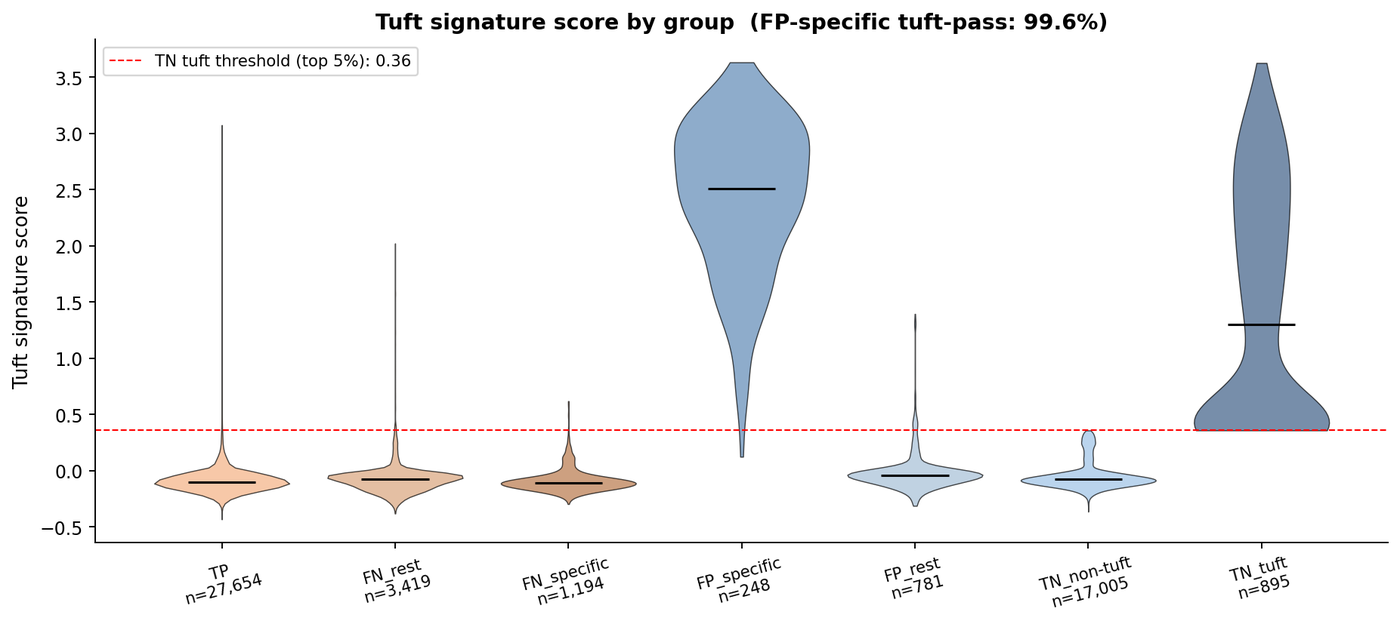

In [ ]:
# Tuft score violin
Image(str(COMP / "umap_FN_FP_clusters/tuft_score_violin.png"))

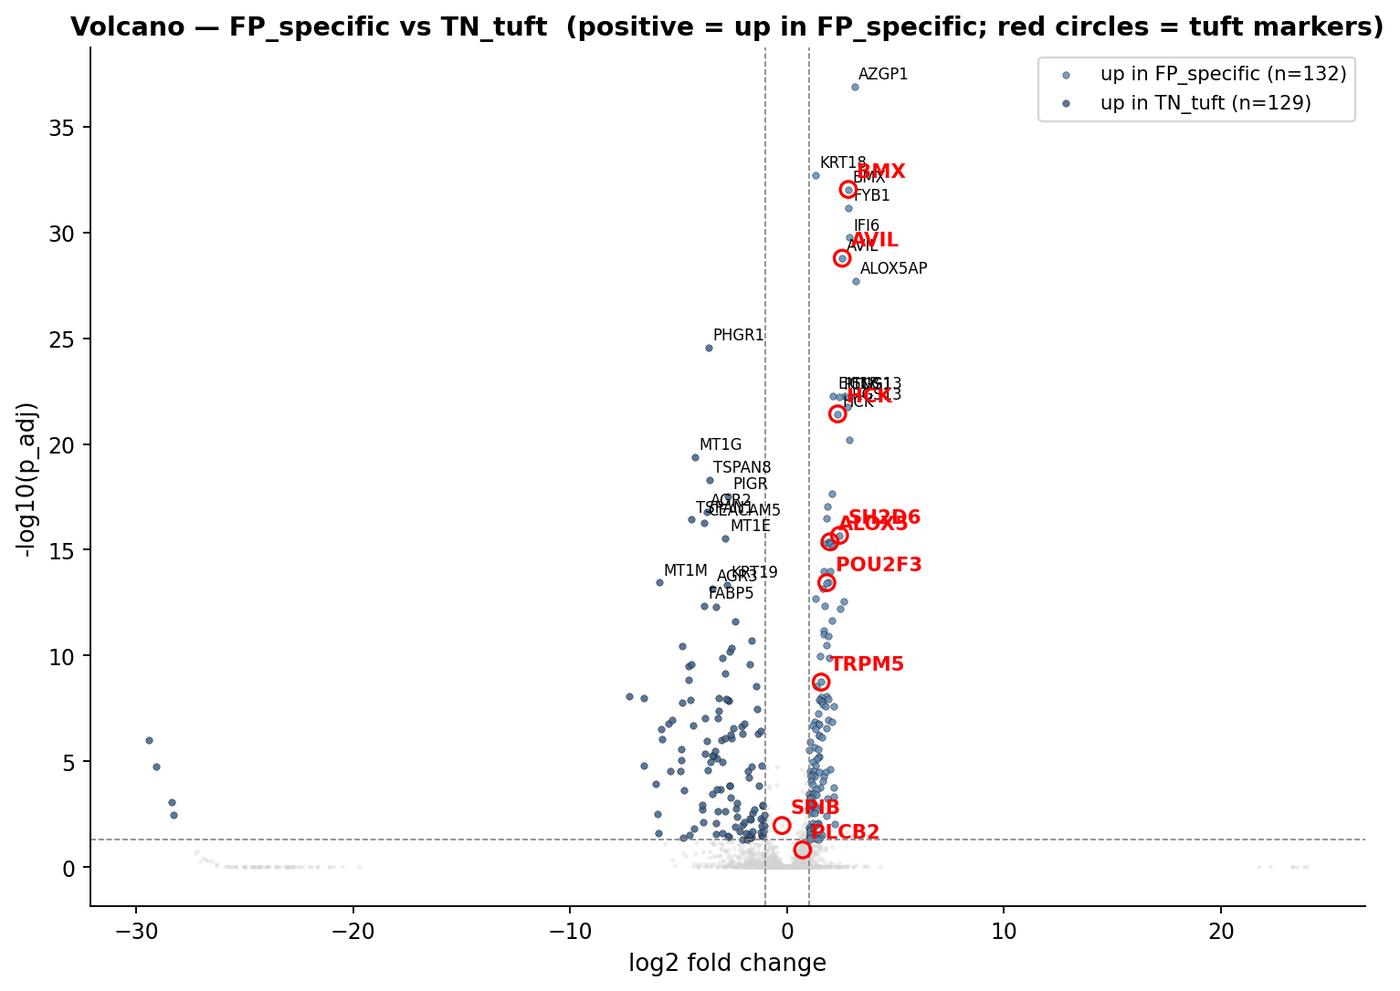

In [ ]:
# Volcano FP-spec vs TN-tuft
Image(str(COMP / "umap_FN_FP_clusters/volcano_FP_specific_vs_TN_tuft.png"))

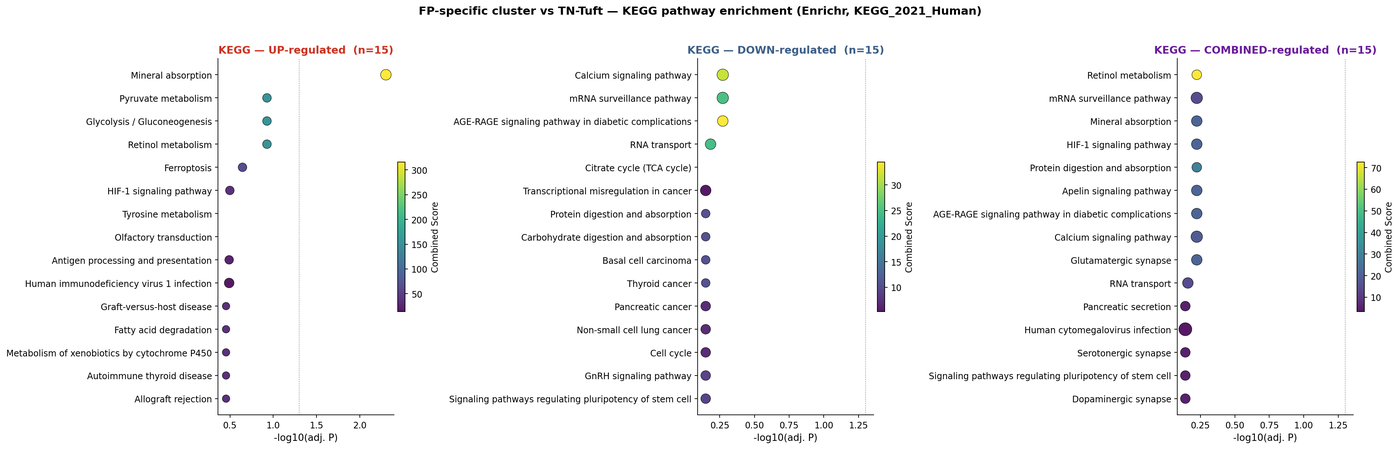

In [ ]:
# KEGG dot-plot
Image(str(COMP / "umap_FN_FP_clusters/KEGG_FPspecific_vs_TN_Tuft_dotplot.png"))